# QAT (Quantization-Aware Training) – Static
## Lung Cancer Classification (CNN + Attention + SVM)

Fine-tune model dengan **fake quantization** lalu konversi ke TFLite  
menggunakan **static quantization** (dengan `representative_dataset`).

| | PTQ Static | **QAT Static** | Dynamic |
|---|---|---|---|
| Fine-tuning | ❌ No | ✅ **Yes** | ❌ No |
| Representative dataset | ✅ Yes | ✅ **Yes** | ❌ No |
| Activation scale | Offline | **Offline** | Online |
| Accuracy (INT8) | Good | **Best** | Good |

## 1. Setup Environment

> ⚠️ **Wajib pertama** – sebelum import TensorFlow apapun.

In [28]:
import os
os.environ["TF_USE_LEGACY_KERAS"] = "1"
print("✅ TF_USE_LEGACY_KERAS=1 set")


✅ TF_USE_LEGACY_KERAS=1 set


## 2. Imports

In [29]:
import time, json, shutil
from datetime import datetime
import numpy as np
import pandas as pd
import joblib
import cv2
import tensorflow as tf
import tf_keras
from tf_keras.models import Model
from tf_keras.layers import (Layer, Conv2D, MaxPooling2D, Flatten, Dense,
                             GlobalAveragePooling2D, Reshape, Multiply, Input)
from tf_keras.callbacks import EarlyStopping
from tf_keras.utils import to_categorical
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler, label_binarize
from sklearn.metrics import (accuracy_score, classification_report,
                             confusion_matrix, roc_auc_score)
import tensorflow_model_optimization as tfmot
import matplotlib.pyplot as plt
import seaborn as sns

SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

print(f"TensorFlow : {tf.__version__}")
print(f"tf_keras   : {tf_keras.__version__}")
print(f"GPU        : {len(tf.config.list_physical_devices('GPU'))} device(s)")


TensorFlow : 2.21.0
tf_keras   : 2.21.0
GPU        : 0 device(s)


## 3. Custom Layer

In [30]:
class ChannelAttention(Layer):
    def __init__(self, ratio=8, **kwargs):
        super().__init__(**kwargs)
        self.ratio = ratio

    def build(self, input_shape):
        ch = input_shape[-1]
        self.gap     = GlobalAveragePooling2D()
        self.dense1  = Dense(max(1, ch // self.ratio), activation="relu")
        self.dense2  = Dense(ch, activation="sigmoid")
        self.reshape = Reshape((1, 1, ch))
        super().build(input_shape)

    def call(self, x):
        a = self.gap(x); a = self.dense1(a); a = self.dense2(a); a = self.reshape(a)
        return Multiply()([x, a])

    def get_config(self):
        cfg = super().get_config(); cfg.update({"ratio": self.ratio}); return cfg

CUSTOM_OBJECTS = {"ChannelAttention": ChannelAttention}
print("✅ ChannelAttention defined")


✅ ChannelAttention defined


## 4. Architecture Builder

> ⚠️ Sesuaikan dengan arsitektur model Anda.

In [31]:
def build_model_tfkeras(input_shape=(224,224,3), num_classes=3):
    inputs   = Input(shape=input_shape)
    x        = Conv2D(64, 3, padding="same", activation="relu")(inputs)
    x        = ChannelAttention(ratio=8)(x)
    x        = MaxPooling2D(2)(x)
    x        = Conv2D(32, 3, padding="same", activation="relu")(x)
    x        = ChannelAttention(ratio=8)(x)
    x        = MaxPooling2D(2)(x)
    x        = Flatten()(x)
    features = Dense(16, activation="relu", name="feature_layer")(x)
    output   = Dense(num_classes, activation="softmax", name="softmax_output")(features)
    return Model(inputs, output, name="CNN_Attention_tfkeras")

print("✅ Architecture defined")


✅ Architecture defined


## 5. Helper Functions

In [32]:
def get_size_kb(path):
    return os.path.getsize(path) / 1024 if os.path.exists(path) else 0.0

def get_total_size_kb(*paths):
    """Total size semua file: TFLite/Keras + SVM + scaler"""
    return sum(os.path.getsize(p) / 1024 for p in paths if os.path.exists(p))

class TFLiteExtractor:
    def __init__(self, path):
        self.interp = tf.lite.Interpreter(model_path=path)
        self.interp.allocate_tensors()
        self.inp = self.interp.get_input_details()
        self.out = self.interp.get_output_details()
    def predict(self, X, verbose=0, batch_size=None):
        feats = []
        for img in X:
            self.interp.set_tensor(self.inp[0]['index'], img[np.newaxis].astype(np.float32))
            self.interp.invoke()
            feats.append(self.interp.get_tensor(self.out[0]['index'])[0])
        return np.array(feats)

def evaluate_model(extractor, svm, scaler, X, y_true, class_names, label):
    t0 = time.time(); feats = extractor.predict(X, verbose=0, batch_size=16); feat_time = time.time()-t0
    t0 = time.time(); X_sc = scaler.transform(feats); y_pred = svm.predict(X_sc); y_prob = svm.predict_proba(X_sc); inf_time = time.time()-t0
    acc = accuracy_score(y_true, y_pred); cm = confusion_matrix(y_true, y_pred)
    rep = classification_report(y_true, y_pred, target_names=class_names, output_dict=True)
    sens=rep['macro avg']['recall']; prec=rep['macro avg']['precision']; f1=rep['macro avg']['f1-score']
    specs=[]
    for i in range(len(class_names)):
        tn=cm.sum()-cm[i,:].sum()-cm[:,i].sum()+cm[i,i]; fp=cm[:,i].sum()-cm[i,i]
        specs.append(tn/(tn+fp) if (tn+fp)>0 else 0)
    y_bin = label_binarize(y_true, classes=range(len(class_names)))
    auc = roc_auc_score(y_bin, y_prob, average='macro', multi_class='ovr')
    return dict(label=label, accuracy=acc, sensitivity=sens, specificity=np.mean(specs),
                precision=prec, f1=f1, auc=auc, cm=cm, feat_time=feat_time, inf_time=inf_time)

def make_concrete_fn(keras_model):
    spec = tf.TensorSpec(shape=tuple(keras_model.input_shape), dtype=tf.float32, name="input")
    class _W(tf.Module):
        def __init__(self,m): super().__init__(); self.m=m
        @tf.function(input_signature=[spec])
        def __call__(self,x): return self.m(x, training=False)
    w=_W(keras_model); return w.__call__.get_concrete_function(), w

def load_weights_from_keras3(tfk_model, keras_path):
    import zipfile, tempfile, h5py
    with zipfile.ZipFile(keras_path,'r') as z:
        with tempfile.TemporaryDirectory() as tmp:
            z.extract('model.weights.h5', tmp)
            tfk_layers=[l for l in tfk_model.layers if l.weights]
            with h5py.File(os.path.join(tmp,'model.weights.h5'),'r') as f:
                if 'layers' not in f: return
                names=sorted(f['layers'].keys()); used=set()
                def col(g):
                    r=[]
                    if 'vars' in g:
                        for v in sorted(g['vars'].keys()): r.append(np.array(g['vars'][v]))
                    for k in sorted(g.keys()):
                        if k!='vars' and isinstance(g[k],h5py.Group): r.extend(col(g[k]))
                    return r
                for lyr in tfk_layers:
                    ts=[w.shape for w in lyr.get_weights()]
                    for nm in names:
                        if nm in used: continue
                        wl=col(f['layers'][nm])
                        if [w.shape for w in wl]==ts: lyr.set_weights(wl); used.add(nm); break
    print(f"  ✅ Weights loaded from {os.path.basename(keras_path)}")

print("✅ Helper functions defined")


✅ Helper functions defined


## 6. Load Dataset

In [33]:
print("="*70); print("LOADING DATASET"); print("="*70)
SCRIPT_DIR = os.getcwd()
for c in [os.path.join(os.path.dirname(SCRIPT_DIR),"dataset_processed2"),
          "../dataset_processed2","dataset_processed2"]:
    if os.path.exists(c): dataset_base_path=c; break

IMG_SIZE=224; categories=["Bengin cases","Malignant cases","Normal cases"]
class_names=["Bengin","Malignant","Normal"]

def load_split(split):
    X,y=[],[]
    for idx,cat in enumerate(categories):
        cp=os.path.join(dataset_base_path,split,cat)
        if not os.path.isdir(cp): continue
        for fn in sorted(os.listdir(cp)):
            if not fn.lower().endswith((".jpg",".jpeg",".png")): continue
            img=cv2.imread(os.path.join(cp,fn))
            if img is None: continue
            img=cv2.cvtColor(img,cv2.COLOR_BGR2RGB); img=cv2.resize(img,(IMG_SIZE,IMG_SIZE))
            X.append(img.astype(np.float32)/255.0); y.append(idx)
    return np.array(X,dtype=np.float32),np.array(y)

print("Loading …")
X_train,y_train_int=load_split("train"); X_valid,y_valid_int=load_split("valid"); X_test,y_test_int=load_split("test")
y_train=to_categorical(y_train_int,3); y_valid=to_categorical(y_valid_int,3)
print(f"Train:{X_train.shape}  Valid:{X_valid.shape}  Test:{X_test.shape}")


LOADING DATASET
Loading …
Train:(737, 224, 224, 3)  Valid:(158, 224, 224, 3)  Test:(159, 224, 224, 3)


## 7. Load Baseline Model

> ⚠️ Update `ORIG_FOLDER` sesuai path hasil training Anda.

In [34]:
print("="*70); print("LOADING BASELINE MODEL"); print("="*70)

ORIG_FOLDER = "saved_models_original"   # ⚠️ UPDATE THIS
if not os.path.isdir(ORIG_FOLDER):
    raise FileNotFoundError(f"'{ORIG_FOLDER}' tidak ditemukan.")

cnn_path = os.path.join(ORIG_FOLDER, "cnn_attention_model.keras")
print("Building tf_keras model …")
model_orig = build_model_tfkeras((IMG_SIZE,IMG_SIZE,3), 3)
_ = model_orig(X_train[:1])
load_weights_from_keras3(model_orig, cnn_path)
extractor_orig = Model(model_orig.input, model_orig.get_layer("feature_layer").output)

svm_orig    = joblib.load(os.path.join(ORIG_FOLDER, "svm_classifier.pkl"))
scaler_orig = joblib.load(os.path.join(ORIG_FOLDER, "feature_scaler.pkl"))
print(f"✅ Loaded  |  Params: {model_orig.count_params():,}")

print("\nEvaluating baseline …")
metrics_orig = evaluate_model(extractor_orig, svm_orig, scaler_orig,
                               X_test, y_test_int, class_names, "Baseline (FP32)")
print(f"✅ Baseline Accuracy: {metrics_orig['accuracy']:.4f}")


LOADING BASELINE MODEL
Building tf_keras model …
  ✅ Weights loaded from cnn_attention_model.keras
✅ Loaded  |  Params: 1,627,343

Evaluating baseline …
✅ Baseline Accuracy: 0.9937


## 8. QAT INT8 Pipeline (Static)

In [35]:
print("="*70); print("QAT INT8 PIPELINE (STATIC)"); print("="*70)

model_qat_int8 = build_model_tfkeras((IMG_SIZE,IMG_SIZE,3), 3)
_ = model_qat_int8(X_train[:1])
load_weights_from_keras3(model_qat_int8, cnn_path)

qal=tfmot.quantization.keras.quantize_annotate_layer
q_app=tfmot.quantization.keras.quantize_apply
q_scp=tfmot.quantization.keras.quantize_scope

def annotate(layer):
    if isinstance(layer,(Conv2D,Dense,MaxPooling2D,Flatten)): return qal(layer)
    return layer

annotated = tf_keras.models.clone_model(model_qat_int8, clone_function=annotate)
with q_scp({"ChannelAttention":ChannelAttention}):
    model_qat_int8 = q_app(annotated)

model_qat_int8.compile(optimizer=tf_keras.optimizers.Adam(1e-4),
                        loss="categorical_crossentropy", metrics=["accuracy"])

print("Fine-tuning dengan fake quantization (5 epochs) …")
model_qat_int8.fit(X_train, y_train, validation_data=(X_valid,y_valid),
                   epochs=5, batch_size=8, verbose=1)

# Convert – STATIC (dengan representative_dataset)
print("\nConverting to TFLite INT8 (static) …")
feat_layer_name = next(l.name for l in model_qat_int8.layers if "feature_layer" in l.name)
ext_qat_int8 = Model(model_qat_int8.input, model_qat_int8.get_layer(feat_layer_name).output)
concrete, wrapper = make_concrete_fn(ext_qat_int8)

conv = tf.lite.TFLiteConverter.from_concrete_functions([concrete], wrapper)
conv.optimizations = [tf.lite.Optimize.DEFAULT]

def rep_data():
    for i in range(100): yield [X_train[i:i+1]]

conv.representative_dataset = rep_data                                  # ← STATIC!
conv.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS_INT8]
conv.inference_input_type  = tf.float32
conv.inference_output_type = tf.float32

tflite_int8 = conv.convert()
os.makedirs("artifacts", exist_ok=True)
path_int8 = "artifacts/qat_int8.tflite"
with open(path_int8,"wb") as f: f.write(tflite_int8)
size_int8 = len(tflite_int8)/1024
print(f"✅ QAT INT8 saved  |  Size: {size_int8:.2f} KB")

print("\nExtracting features …")
ex_int8    = TFLiteExtractor(path_int8)
X_tr_i8    = ex_int8.predict(X_train)
X_val_i8   = ex_int8.predict(X_valid)

scaler_int8 = StandardScaler()
X_sc_i8     = scaler_int8.fit_transform(np.vstack([X_tr_i8, X_val_i8]))
y_comb      = np.concatenate([y_train_int, y_valid_int])

svm_int8 = SVC(kernel='rbf', C=0.5, gamma='scale', probability=True, random_state=SEED, class_weight="balanced")
svm_int8.fit(X_sc_i8, y_comb)

metrics_int8 = evaluate_model(ex_int8, svm_int8, scaler_int8,
                               X_test, y_test_int, class_names, "QAT INT8")
print(f"✅ QAT INT8 Accuracy: {metrics_int8['accuracy']:.4f}")


QAT INT8 PIPELINE (STATIC)
  ✅ Weights loaded from cnn_attention_model.keras
Fine-tuning dengan fake quantization (5 epochs) …
Epoch 1/5
93/93 [==============================] - 23s 242ms/step - loss: 0.2691 - accuracy: 0.9159 - val_loss: 0.1398 - val_accuracy: 0.9810
Epoch 2/5
93/93 [==============================] - 32s 344ms/step - loss: 0.1003 - accuracy: 0.9891 - val_loss: 0.0876 - val_accuracy: 0.9747
Epoch 3/5
93/93 [==============================] - 39s 421ms/step - loss: 0.0601 - accuracy: 0.9959 - val_loss: 0.0690 - val_accuracy: 0.9873
Epoch 4/5
93/93 [==============================] - 41s 437ms/step - loss: 0.0421 - accuracy: 0.9959 - val_loss: 0.0590 - val_accuracy: 0.9937
Epoch 5/5
93/93 [==============================] - 41s 436ms/step - loss: 0.0323 - accuracy: 0.9973 - val_loss: 0.0553 - val_accuracy: 0.9937

Converting to TFLite INT8 (static) …
INFO:tensorflow:Assets written to: C:\Users\User\AppData\Local\Temp\tmp8dt1utsf\assets


INFO:tensorflow:Assets written to: C:\Users\User\AppData\Local\Temp\tmp8dt1utsf\assets


✅ QAT INT8 saved  |  Size: 1604.60 KB

Extracting features …


d:\bintang\.venv\lib\site-packages\tensorflow\lite\python\interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)


✅ QAT INT8 Accuracy: 0.9874


## 9. QAT FP16 Pipeline (Static)

In [36]:
print("="*70); print("QAT FP16 PIPELINE (STATIC)"); print("="*70)

model_qat_fp16 = build_model_tfkeras((IMG_SIZE,IMG_SIZE,3), 3)
_ = model_qat_fp16(X_train[:1])
load_weights_from_keras3(model_qat_fp16, cnn_path)
model_qat_fp16.compile(optimizer=tf_keras.optimizers.Adam(1e-4),
                        loss="categorical_crossentropy", metrics=["accuracy"])

print("Fine-tuning (5 epochs) …")
model_qat_fp16.fit(X_train, y_train, validation_data=(X_valid,y_valid),
                   epochs=5, batch_size=8, verbose=1)

print("\nConverting to TFLite FP16 (static) …")
ext_qat_fp16 = Model(model_qat_fp16.input, model_qat_fp16.get_layer("feature_layer").output)
concrete2, wrapper2 = make_concrete_fn(ext_qat_fp16)

conv2 = tf.lite.TFLiteConverter.from_concrete_functions([concrete2], wrapper2)
conv2.optimizations = [tf.lite.Optimize.DEFAULT]
conv2.target_spec.supported_types = [tf.float16]

tflite_fp16 = conv2.convert()
path_fp16 = "artifacts/qat_fp16.tflite"
with open(path_fp16,"wb") as f: f.write(tflite_fp16)
size_fp16 = len(tflite_fp16)/1024
print(f"✅ QAT FP16 saved  |  Size: {size_fp16:.2f} KB")

print("\nExtracting features …")
ex_fp16    = TFLiteExtractor(path_fp16)
X_tr_f16   = ex_fp16.predict(X_train)
X_val_f16  = ex_fp16.predict(X_valid)

scaler_fp16 = StandardScaler()
X_sc_f16    = scaler_fp16.fit_transform(np.vstack([X_tr_f16, X_val_f16]))

svm_fp16 = SVC(kernel='rbf', C=0.5, gamma='scale', probability=True, random_state=SEED, class_weight="balanced")
svm_fp16.fit(X_sc_f16, y_comb)

metrics_fp16 = evaluate_model(ex_fp16, svm_fp16, scaler_fp16,
                               X_test, y_test_int, class_names, "QAT FP16")
print(f"✅ QAT FP16 Accuracy: {metrics_fp16['accuracy']:.4f}")


QAT FP16 PIPELINE (STATIC)
  ✅ Weights loaded from cnn_attention_model.keras
Fine-tuning (5 epochs) …
Epoch 1/5
93/93 [==============================] - 17s 179ms/step - loss: 0.0129 - accuracy: 0.9973 - val_loss: 0.0601 - val_accuracy: 0.9937
Epoch 2/5
93/93 [==============================] - 17s 179ms/step - loss: 0.0136 - accuracy: 0.9959 - val_loss: 0.0460 - val_accuracy: 0.9937
Epoch 3/5
93/93 [==============================] - 16s 169ms/step - loss: 0.0127 - accuracy: 0.9959 - val_loss: 0.0484 - val_accuracy: 0.9937
Epoch 4/5
93/93 [==============================] - 15s 159ms/step - loss: 0.0131 - accuracy: 0.9973 - val_loss: 0.0549 - val_accuracy: 0.9937
Epoch 5/5
93/93 [==============================] - 15s 159ms/step - loss: 0.0114 - accuracy: 0.9973 - val_loss: 0.0532 - val_accuracy: 0.9937

Converting to TFLite FP16 (static) …
INFO:tensorflow:Assets written to: C:\Users\User\AppData\Local\Temp\tmp59i75c7c\assets


INFO:tensorflow:Assets written to: C:\Users\User\AppData\Local\Temp\tmp59i75c7c\assets


✅ QAT FP16 saved  |  Size: 3188.21 KB

Extracting features …


d:\bintang\.venv\lib\site-packages\tensorflow\lite\python\interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)


✅ QAT FP16 Accuracy: 0.9937


## 10. Save Artifacts

In [37]:
print("="*70); print("SAVING ARTIFACTS"); print("="*70)
timestamp   = datetime.now().strftime('%Y%m%d_%H%M%S')
save_folder = f"saved_models_qat_{timestamp}"
os.makedirs(save_folder, exist_ok=True)

shutil.copy2(path_int8, os.path.join(save_folder, "qat_int8.tflite"))
shutil.copy2(path_fp16, os.path.join(save_folder, "qat_fp16.tflite"))
joblib.dump(svm_int8,    os.path.join(save_folder, "svm_int8.pkl"))
joblib.dump(scaler_int8, os.path.join(save_folder, "scaler_int8.pkl"))
joblib.dump(svm_fp16,    os.path.join(save_folder, "svm_fp16.pkl"))
joblib.dump(scaler_fp16, os.path.join(save_folder, "scaler_fp16.pkl"))
model_orig.save(os.path.join(save_folder, "baseline.keras"))
joblib.dump(svm_orig,    os.path.join(save_folder, "svm_baseline.pkl"))
joblib.dump(scaler_orig, os.path.join(save_folder, "scaler_baseline.pkl"))
print(f"✅ Saved to: {save_folder}/")


SAVING ARTIFACTS
✅ Saved to: saved_models_qat_20260519_134918/


## 11. Comprehensive Comparison Table

**Model Size = TFLite extractor + SVM + Scaler**

In [38]:
print("\n" + "=" * 140)
print("COMPREHENSIVE COMPARISON TABLE - QUANTIZATION-AWARE TRAINING (QAT)")
print("=" * 140)
print("Note: Model Size = TFLite extractor + SVM (.pkl) + Scaler (.pkl)")
print("=" * 140)

all_results = [metrics_orig, metrics_int8, metrics_fp16]

# Baseline size mengikuti notebook referensi: ukuran model Keras asli
size_baseline = get_size_kb(cnn_path)

# Total size = model baseline + SVM + Scaler
size_baseline_total = (size_baseline)

size_int8_total = (size_int8
                   + get_size_kb(os.path.join(save_folder, "svm_int8.pkl"))
                   + get_size_kb(os.path.join(save_folder, "scaler_int8.pkl")))

size_fp16_total = (size_fp16
                   + get_size_kb(os.path.join(save_folder, "svm_fp16.pkl"))
                   + get_size_kb(os.path.join(save_folder, "scaler_fp16.pkl")))

sizes = [size_baseline_total, size_int8_total, size_fp16_total]

rows = []
for m, sz in zip(all_results, sizes):
    rows.append({
        "Model"         : m['label'],
        "Size (KB)"     : f"{sz:.2f}",
        "Compression"   : f"{size_baseline/sz:.2f}x",
        "Accuracy"      : f"{m['accuracy']:.4f}",
        "Sensitivity"   : f"{m['sensitivity']:.4f}",
        "Specificity"   : f"{m['specificity']:.4f}",
        "Precision"     : f"{m['precision']:.4f}",
        "F1-Score"      : f"{m['f1']:.4f}",
        "AUC"           : f"{m['auc']:.4f}",
        "Feat Ext (ms)" : f"{m['feat_time']*1000:.2f}",
        "SVM Inf (ms)"  : f"{m['inf_time']*1000:.2f}",
        "Total (ms)"    : f"{(m['feat_time']+m['inf_time'])*1000:.2f}",
    })

df_comp = pd.DataFrame(rows)
print("\n" + df_comp.to_string(index=False))
print("\n" + "=" * 140)

df_comp.to_csv(os.path.join(save_folder, "comparison.csv"), index=False)

summary = {}
for i, (m, sz) in enumerate(zip(all_results, sizes)):
    key = m['label'].lower().replace(' ','_').replace('(','').replace(')','')
    summary[key] = {
        'accuracy'       : float(m['accuracy']),
        'sensitivity'    : float(m['sensitivity']),
        'specificity'    : float(m['specificity']),
        'precision'      : float(m['precision']),
        'f1'             : float(m['f1']),
        'auc'            : float(m['auc']),
        'size_kb'        : float(sz),
        'feat_time_ms'   : float(m['feat_time']*1000),
        'inf_time_ms'    : float(m['inf_time']*1000),
        'total_time_ms'  : float((m['feat_time']+m['inf_time'])*1000),
        'degradation_pct': float((all_results[0]['accuracy']-m['accuracy'])
                                  /all_results[0]['accuracy']*100) if i>0 else 0.0,
        'speedup'        : float((all_results[0]['feat_time']+all_results[0]['inf_time'])
                                  /(m['feat_time']+m['inf_time'])),
    }
with open(os.path.join(save_folder, "summary.json"), 'w') as f:
    json.dump(summary, f, indent=2)
print("✅ comparison.csv & summary.json saved")



COMPREHENSIVE COMPARISON TABLE - QUANTIZATION-AWARE TRAINING (QAT)
Note: Model Size = TFLite extractor + SVM (.pkl) + Scaler (.pkl)

          Model Size (KB) Compression Accuracy Sensitivity Specificity Precision F1-Score    AUC Feat Ext (ms) SVM Inf (ms) Total (ms)
Baseline (FP32)  19138.72       1.00x   0.9937      0.9945      0.9977    0.9804   0.9871 1.0000       1181.28        12.24    1193.52
       QAT INT8   1617.38      11.83x   0.9874      0.9905      0.9953    0.9630   0.9756 0.9999        852.04         0.00     852.04
       QAT FP16   3204.03       5.97x   0.9937      0.9945      0.9977    0.9804   0.9871 1.0000       1315.78         2.10    1317.89

✅ comparison.csv & summary.json saved


## 12. Visualizations

CREATING VISUALIZATIONS
✅ comparison_plots.png saved


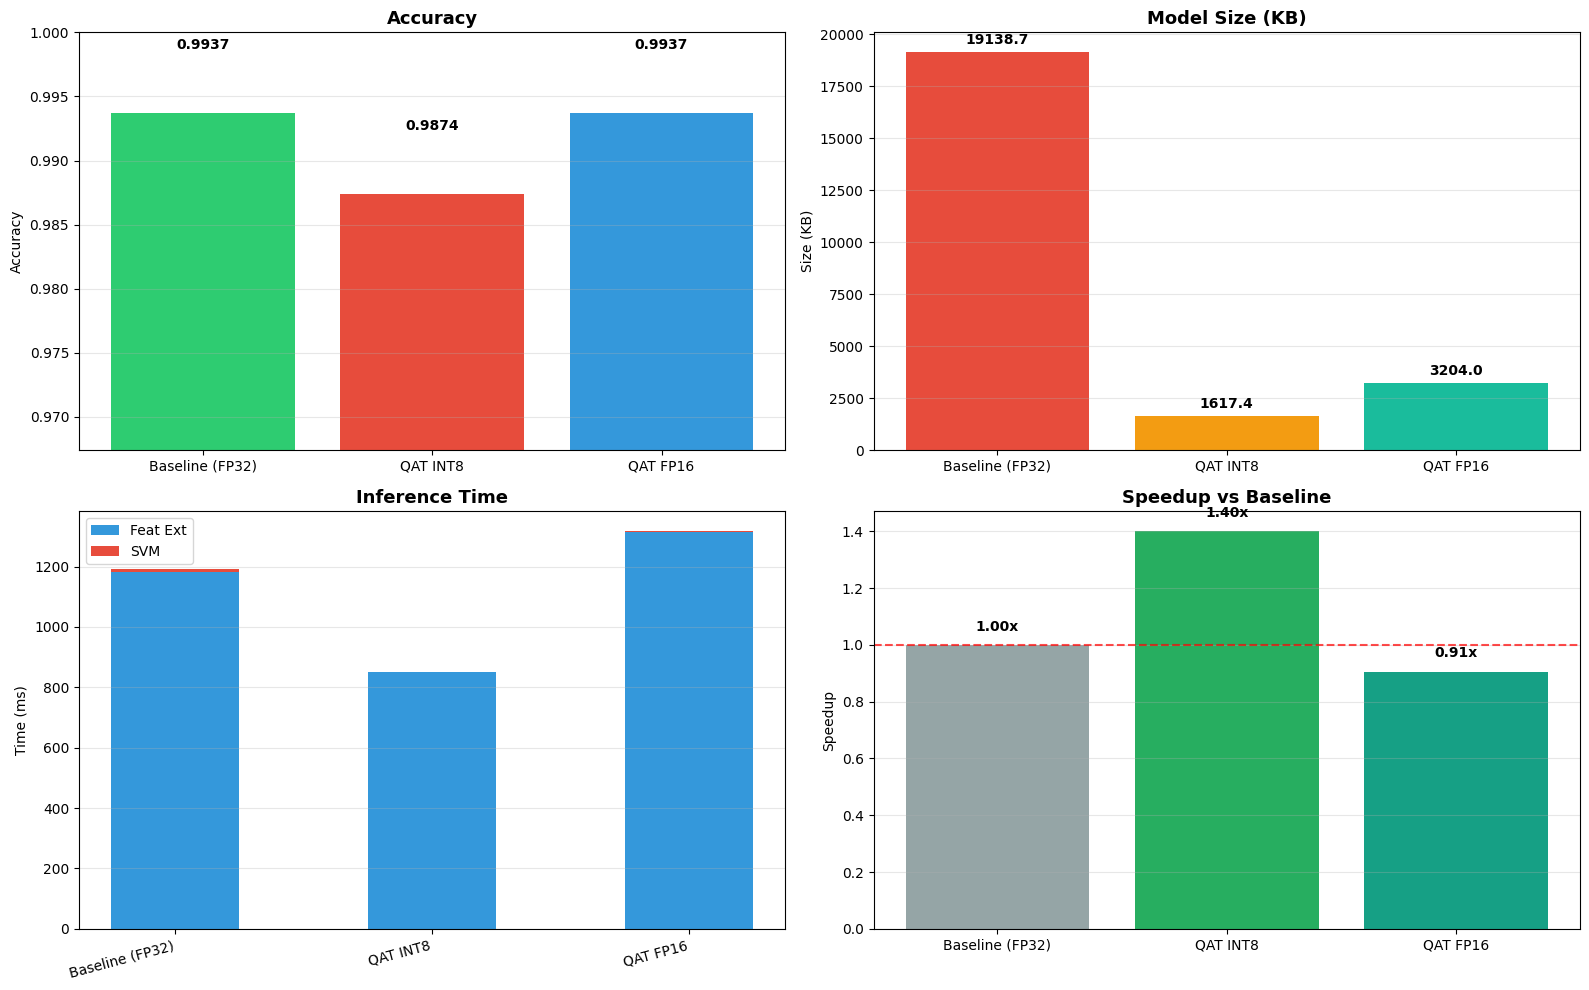

✅ confusion_matrices.png saved


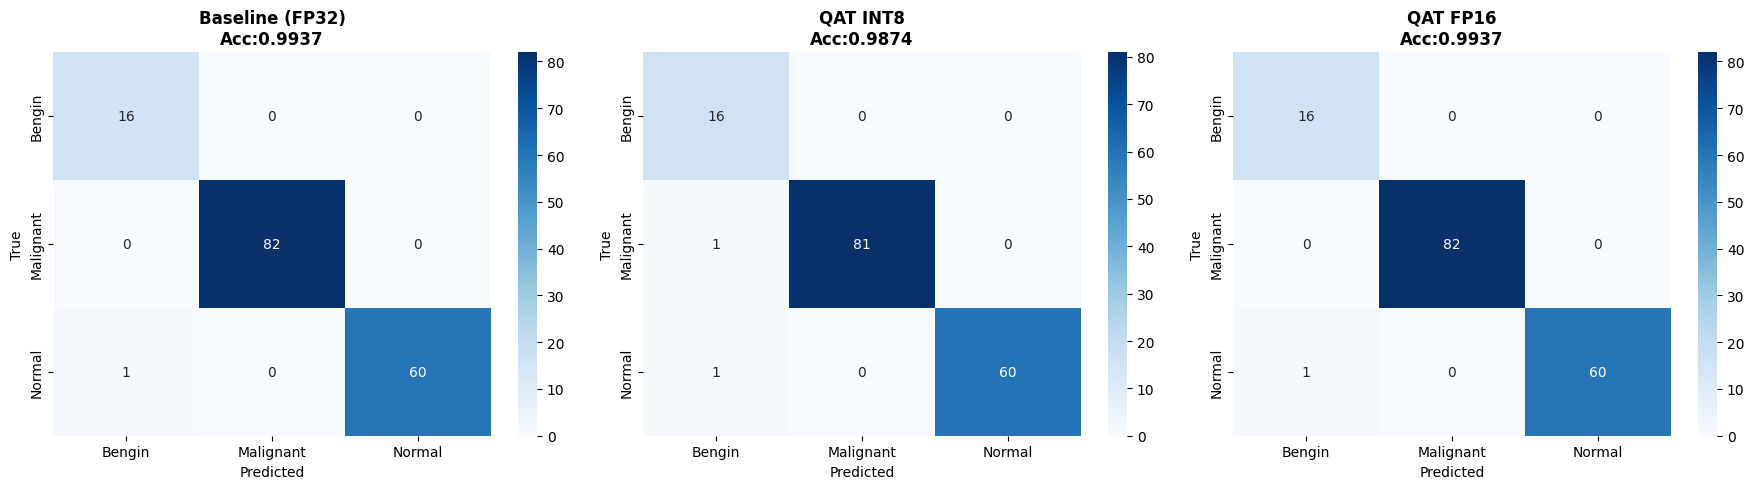

In [39]:
print("="*70); print("CREATING VISUALIZATIONS"); print("="*70)
labels=["Baseline (FP32)","QAT INT8","QAT FP16"]; colors=['#2ecc71','#e74c3c','#3498db']
all_results=[metrics_orig,metrics_int8,metrics_fp16]
fig,axes=plt.subplots(2,2,figsize=(16,10))

acc_v=[m['accuracy'] for m in all_results]
bars=axes[0,0].bar(labels,acc_v,color=colors)
axes[0,0].set_ylim(min(acc_v)-0.02,1.0); axes[0,0].set_title("Accuracy",fontsize=13,fontweight='bold')
axes[0,0].set_ylabel("Accuracy"); axes[0,0].grid(axis='y',alpha=0.3)
for b,v in zip(bars,acc_v): axes[0,0].text(b.get_x()+b.get_width()/2,b.get_height()+0.005,f'{v:.4f}',ha='center',fontweight='bold')

bars=axes[0,1].bar(labels,sizes,color=['#e74c3c','#f39c12','#1abc9c'])
axes[0,1].set_title("Model Size (KB)",fontsize=13,fontweight='bold'); axes[0,1].set_ylabel("Size (KB)"); axes[0,1].grid(axis='y',alpha=0.3)
for b,v in zip(bars,sizes): axes[0,1].text(b.get_x()+b.get_width()/2,b.get_height()+max(sizes)*0.02,f'{v:.1f}',ha='center',fontweight='bold')

ft=[m['feat_time']*1000 for m in all_results]; st=[m['inf_time']*1000 for m in all_results]
x=np.arange(len(labels))
axes[1,0].bar(x,ft,0.5,label='Feat Ext',color='#3498db'); axes[1,0].bar(x,st,0.5,bottom=ft,label='SVM',color='#e74c3c')
axes[1,0].set_xticks(x); axes[1,0].set_xticklabels(labels,rotation=15,ha='right')
axes[1,0].set_ylabel('Time (ms)'); axes[1,0].set_title('Inference Time',fontsize=13,fontweight='bold')
axes[1,0].legend(); axes[1,0].grid(axis='y',alpha=0.3)

tot=[f+s for f,s in zip(ft,st)]; sp=[tot[0]/t for t in tot]
bars=axes[1,1].bar(labels,sp,color=['#95a5a6','#27ae60','#16a085'])
axes[1,1].axhline(1.0,color='red',linestyle='--',alpha=0.7)
axes[1,1].set_title('Speedup vs Baseline',fontsize=13,fontweight='bold'); axes[1,1].set_ylabel('Speedup')
axes[1,1].grid(axis='y',alpha=0.3)
for b,v in zip(bars,sp): axes[1,1].text(b.get_x()+b.get_width()/2,b.get_height()+0.05,f'{v:.2f}x',ha='center',fontweight='bold')

plt.tight_layout()
plt.savefig(os.path.join(save_folder,"comparison_plots.png"),dpi=150,bbox_inches='tight')
print("✅ comparison_plots.png saved"); plt.show(); plt.close()

fig,axes=plt.subplots(1,3,figsize=(18,5))
for ax,m in zip(axes,all_results):
    sns.heatmap(m['cm'],annot=True,fmt='d',cmap='Blues',
                xticklabels=class_names,yticklabels=class_names,ax=ax)
    ax.set_xlabel('Predicted'); ax.set_ylabel('True')
    ax.set_title(f"{m['label']}\nAcc:{m['accuracy']:.4f}",fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(save_folder,"confusion_matrices.png"),dpi=150,bbox_inches='tight')
print("✅ confusion_matrices.png saved"); plt.show(); plt.close()


## 13. Final Summary

In [40]:
print("\n"+"="*70); print("QAT COMPLETE!"); print("="*70)
print(f"\n📁 Saved to: {save_folder}/")
for i,(m,sz) in enumerate(zip(all_results,sizes)):
    deg=(all_results[0]['accuracy']-m['accuracy'])/all_results[0]['accuracy']*100 if i>0 else 0.0
    spd=(all_results[0]['feat_time']+all_results[0]['inf_time'])/(m['feat_time']+m['inf_time'])
    comp=(sizes[0]/sz) if i>0 else 1.0
    print(f"\n{m['label']}:")
    print(f"  Accuracy  : {m['accuracy']:.4f}  ({deg:+.2f}%)")
    print(f"  Size      : {sz:.2f} KB  ({comp:.2f}x compression vs baseline)")
    print(f"  Total time: {(m['feat_time']+m['inf_time'])*1000:.2f} ms  ({spd:.2f}x speedup)")
print("="*70)



QAT COMPLETE!

📁 Saved to: saved_models_qat_20260519_134918/

Baseline (FP32):
  Accuracy  : 0.9937  (+0.00%)
  Size      : 19138.72 KB  (1.00x compression vs baseline)
  Total time: 1193.52 ms  (1.00x speedup)

QAT INT8:
  Accuracy  : 0.9874  (+0.63%)
  Size      : 1617.38 KB  (11.83x compression vs baseline)
  Total time: 852.04 ms  (1.40x speedup)

QAT FP16:
  Accuracy  : 0.9937  (+0.00%)
  Size      : 3204.03 KB  (5.97x compression vs baseline)
  Total time: 1317.89 ms  (0.91x speedup)
